# 247. Strobogrammatic Number II
https://leetcode.com/problems/strobogrammatic-number-ii/

## Complexity Comparison

| Approach | Time | Space | Description |
|----------|------|-------|-------------|
| **Recursive Build** | **O(5^(n/2))** | **O(5^(n/2))** | **Build from center outward** |

## Methodology

We **recursively** build strobogrammatic numbers from the inside out. Base cases: n=0 returns `[""]`, n=1 returns `["0","1","8"]`. For n>=2, we get all strobogrammatic numbers of length n-2, then wrap each with all valid strobogrammatic pairs `(0,0), (1,1), (6,9), (8,8), (9,6)`. We exclude leading zeros (pair `0,0` on the outermost layer) for the final result.

## Solutions

### C#

In [ ]:
// 247. Strobogrammatic Number II
// Time: O(5^(n/2)) | Space: O(5^(n/2))
public class Solution {
    public IList<string> FindStrobogrammatic(int n) {
        return Helper(n, n);
    }
    
    private IList<string> Helper(int n, int target) {
        if (n == 0) return new List<string> { "" };
        if (n == 1) return new List<string> { "0", "1", "8" };
        
        var inner = Helper(n - 2, target);
        var result = new List<string>();
        
        foreach (string s in inner) {
            if (n != target) result.Add("0" + s + "0");
            result.Add("1" + s + "1");
            result.Add("6" + s + "9");
            result.Add("8" + s + "8");
            result.Add("9" + s + "6");
        }
        return result;
    }
}

### Python

In [ ]:
# 247. Strobogrammatic Number II
# Time: O(5^(n/2)) | Space: O(5^(n/2))
class Solution:
    def findStrobogrammatic(self, n: int) -> list[str]:
        def helper(n, target):
            if n == 0:
                return ['']
            if n == 1:
                return ['0', '1', '8']
            
            inner = helper(n - 2, target)
            result = []
            for s in inner:
                if n != target:
                    result.append('0' + s + '0')
                result.append('1' + s + '1')
                result.append('6' + s + '9')
                result.append('8' + s + '8')
                result.append('9' + s + '6')
            return result
        
        return helper(n, n)

### Go

In [ ]:
// 247. Strobogrammatic Number II
// Time: O(5^(n/2)) | Space: O(5^(n/2))
func findStrobogrammatic(n int) []string {
    return helper(n, n)
}

func helper(n, target int) []string {
    if n == 0 {
        return []string{""}
    }
    if n == 1 {
        return []string{"0", "1", "8"}
    }
    
    inner := helper(n-2, target)
    var result []string
    
    for _, s := range inner {
        if n != target {
            result = append(result, "0"+s+"0")
        }
        result = append(result, "1"+s+"1")
        result = append(result, "6"+s+"9")
        result = append(result, "8"+s+"8")
        result = append(result, "9"+s+"6")
    }
    return result
}

### Rust

In [ ]:
// 247. Strobogrammatic Number II
// Time: O(5^(n/2)) | Space: O(5^(n/2))
impl Solution {
    pub fn find_strobogrammatic(n: i32) -> Vec<String> {
        Self::helper(n, n)
    }
    
    fn helper(n: i32, target: i32) -> Vec<String> {
        if n == 0 {
            return vec![String::new()];
        }
        if n == 1 {
            return vec!["0".into(), "1".into(), "8".into()];
        }
        
        let inner = Self::helper(n - 2, target);
        let mut result = Vec::new();
        let pairs = if n != target {
            vec![("0","0"),("1","1"),("6","9"),("8","8"),("9","6")]
        } else {
            vec![("1","1"),("6","9"),("8","8"),("9","6")]
        };
        
        for s in &inner {
            for &(l, r) in &pairs {
                result.push(format!("{}{}{}", l, s, r));
            }
        }
        result
    }
}

## Example Scenarios

1. **Common Case** — n = 2  
   **Input:** `n = 2`  
   Build from base case (empty string) by wrapping with pairs. Exclude leading-zero pair $(0,0)$ at outermost level. Result: $["11", "69", "88", "96"]$ — four numbers.

2. **Slightly Complex** — n = 3 (odd length)  
   **Input:** `n = 3`  
   Base case for odd $n$ is $["0", "1", "8"]$. Wrap each with all $5$ pairs, excluding leading zeros: e.g., $"1" \to "111", "619", "818", "916"$, etc. Total: $4 \times 3 = 12$ results.

3. **Edge Case: Time Factor** — n = 4 (exponential growth)  
   **Input:** `n = 4`  
   Recursion: $n=0 \to [""]$, $n=2 \to 5$ strings (with inner zeros), $n=4 \to 4 \times 5 = 20$ strings (no leading zeros). Each recursion level multiplies by $5$ (inner) or $4$ (outer). Output size grows as $O(5^{n/2})$.

4. **Edge Case: Space Factor** — n = 1 (minimal)  
   **Input:** `n = 1`  
   Single-digit strobogrammatic numbers: $["0", "1", "8"]$. This is the base case — no recursion needed. Output space is $O(1)$ in terms of count (just $3$ strings).

5. **Almost-Impossible but Plausible** — n = 14  
   **Input:** `n = 14`  
   Recursion depth $= 7$ levels. Output size $\approx 4 \times 5^6 = 62{,}500$ strings, each of length $14$. Total characters $\approx 8.75 \times 10^5$. The $O(5^{n/2})$ time and space is manageable but grows quickly — $n = 16$ would produce $312{,}500$ strings.

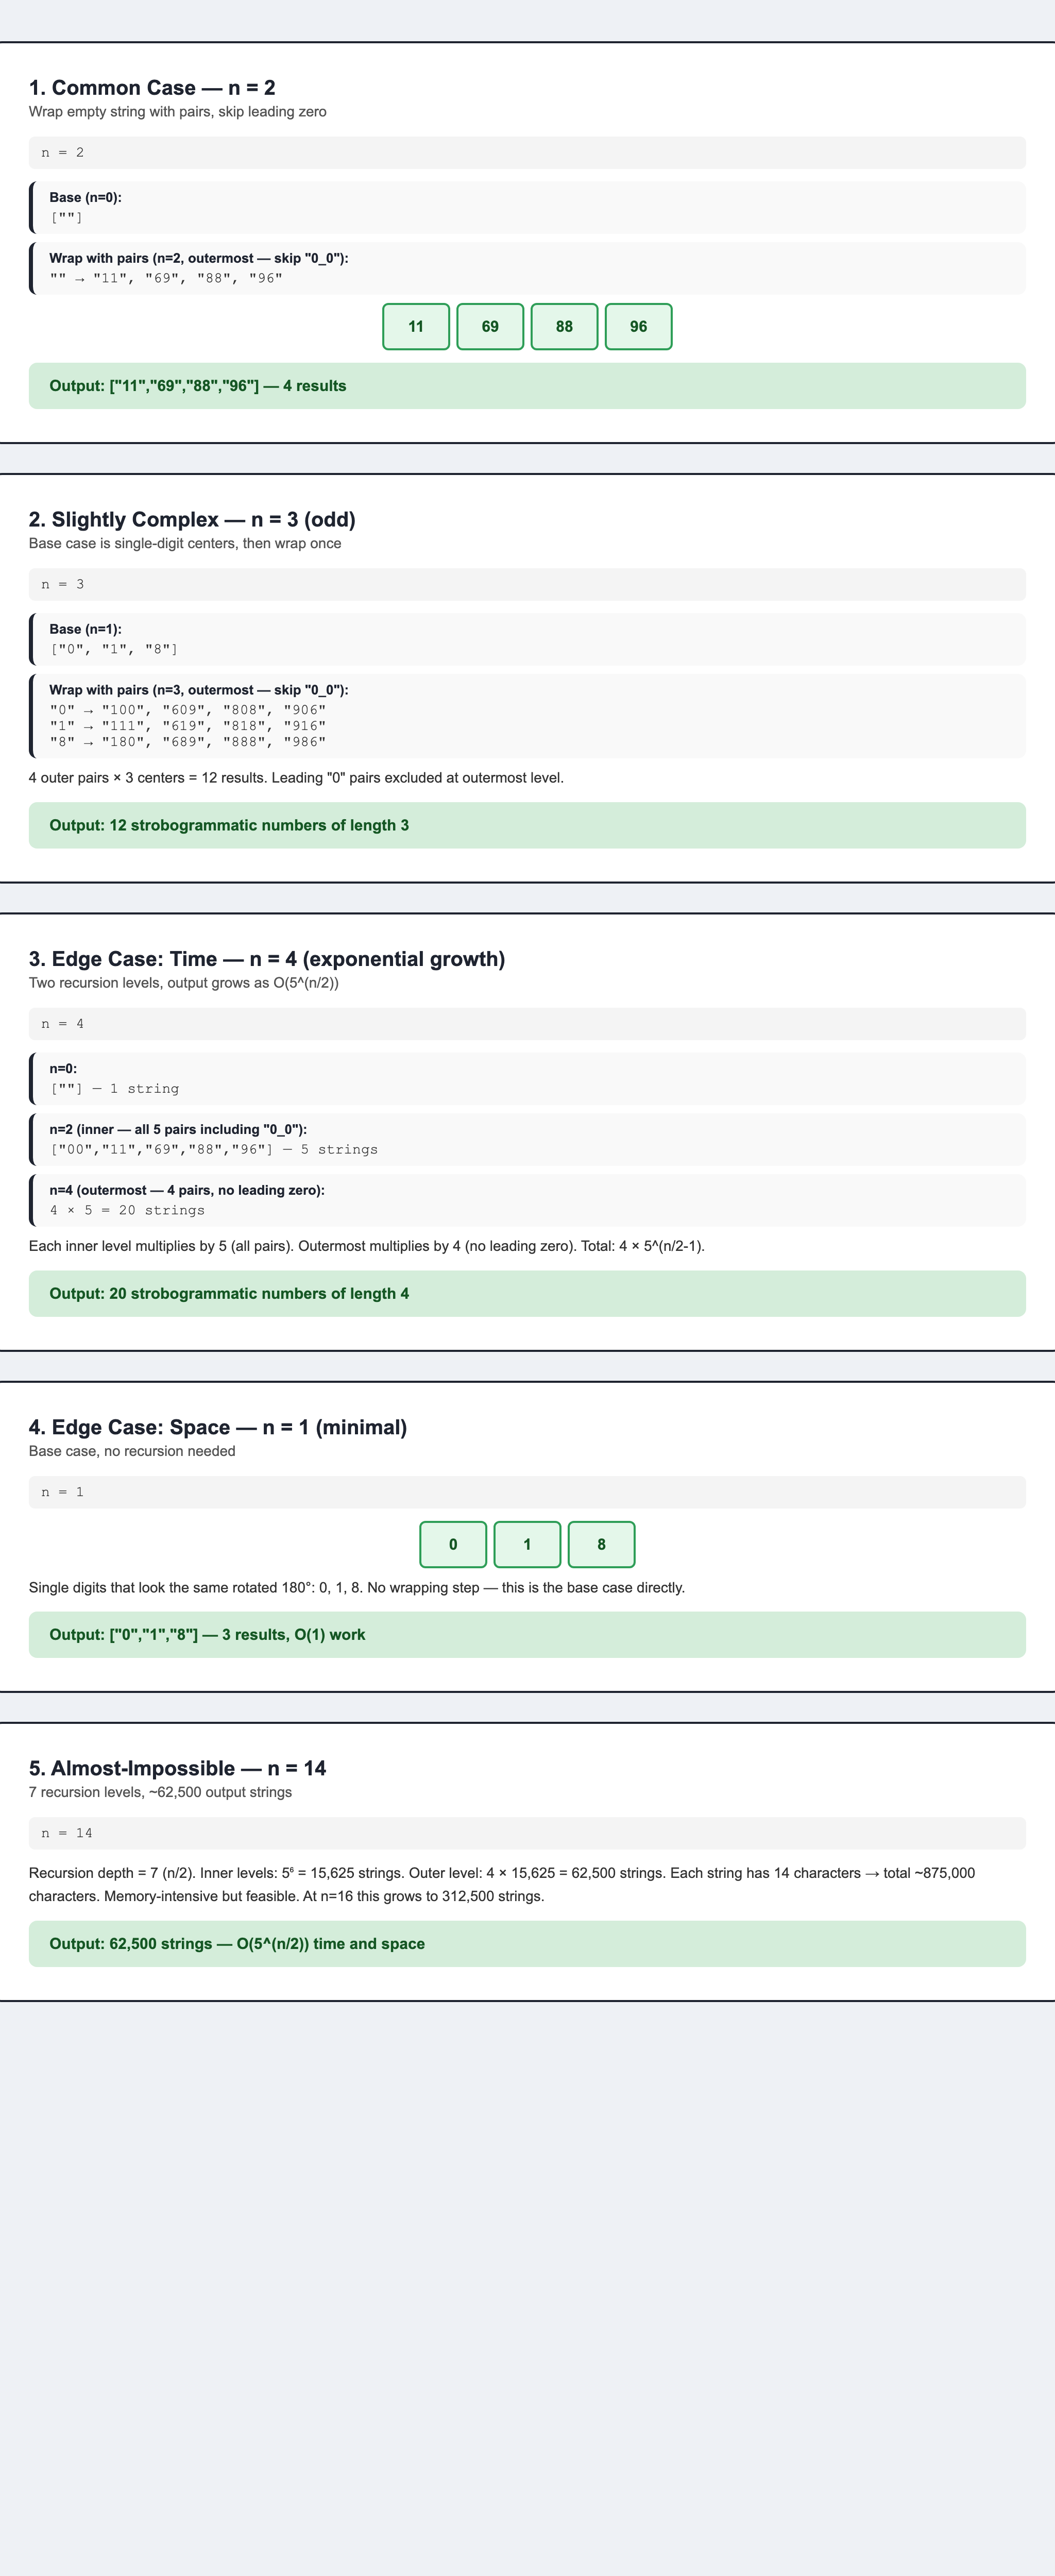